# Logistic regression model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# ls

In [3]:
df=  pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Feature selection

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
col = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 
       'Parch', 'Fare', 'Cabin', 'Embarked']

df = df[col]

In [6]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# data cleaning

In [7]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [9]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [10]:
for i in df.columns:
    print(df[i].value_counts())
    print()

Survived
0    549
1    342
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex
male      577
female    314
Name: count, dtype: int64

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

Embarked
S    644
C    168


In [11]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [12]:
# keeping only the first char
df['Cabin']  = df.Cabin.str.slice(0,1)

In [13]:
df.Cabin.value_counts()

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [14]:
df.Cabin

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Cabin, Length: 891, dtype: object

In [15]:
df['Cabin'] =  df.Cabin.fillna("Na")

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,Na,S
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,Na,S
3,1,1,female,35.0,1,0,53.1000,C,S
4,0,3,male,35.0,0,0,8.0500,Na,S


In [17]:
pd.crosstab(df['Cabin'],df['Embarked'])

Embarked,C,Q,S
Cabin,,,
A,7,0,8
B,22,0,23
C,21,2,36
D,13,0,20
E,5,1,26
F,1,1,11
G,0,0,4
Na,99,73,515
T,0,0,1


In [18]:
# cleaning age column
df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [19]:
df['Age'] = df['Age'].fillna(29)

In [20]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,Na,S
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,Na,S
3,1,1,female,35.0,1,0,53.1000,C,S
4,0,3,male,35.0,0,0,8.0500,Na,S


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     891 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [22]:
# cleaning Embarked column
df['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [23]:
df['Embarked'] = df['Embarked'].fillna("S")

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     891 non-null    object 
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


# spliting the data

In [25]:
x = df.drop(columns="Survived")
y = df['Survived']

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [27]:
print(x_train.shape)
x_train.head(2)

(712, 8)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
301,3,male,29.0,2,0,23.2500,Na,Q
309,1,female,30.0,0,0,56.9292,E,C


In [28]:
print(x_test.shape)
x_test.head(2)

(179, 8)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
862,1,female,48.0,0,0,25.9292,D,S
223,3,male,29.0,0,0,7.8958,Na,S


In [29]:
print(y_train.shape)
y_train.head(2)

(712,)


301    1
309    1
Name: Survived, dtype: int64

In [30]:
print(y_test.shape)
y_test.head()

(179,)


862    1
223    0
84     1
680    0
535    1
Name: Survived, dtype: int64

# using column transformer 
to transform data numerical and categorical

In [31]:
num = x.select_dtypes(include=np.number).columns
cat = x.select_dtypes(include="object").columns

In [32]:
print(num)
print(cat)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Index(['Sex', 'Cabin', 'Embarked'], dtype='object')


In [33]:
# check if there are any outlier
# for i in num:
#     sns.boxplot(df[i])
#     plt.show()


In [34]:
transformer = ColumnTransformer(
    [
        ("scaler",StandardScaler(),num),
        ("encoder",OneHotEncoder(),cat)
    ]
)

transformed_data = transformer.fit_transform(x_train)

print(transformed_data)

[[ 0.83659324 -0.0701322   1.49105341 ...  0.          1.
   0.        ]
 [-1.55559305  0.00524917 -0.48959963 ...  1.          0.
   0.        ]
 [-0.35949991  0.30677464 -0.48959963 ...  0.          0.
   1.        ]
 ...
 [-0.35949991 -0.67318314 -0.48959963 ...  0.          0.
   1.        ]
 [ 0.83659324 -0.0701322  -0.48959963 ...  0.          0.
   1.        ]
 [ 0.83659324 -0.67318314 -0.48959963 ...  0.          0.
   1.        ]]


# creating pipeline

In [35]:
Pipe = Pipeline(
    [
        ("transform",transformer),
        ("model",LogisticRegression())
    ]
)

In [36]:
Pipe.fit(x_train,y_train)

,steps,"[('transform', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
prediction = Pipe.predict(x_test)

# checking accuracy

In [38]:
# Accuracy in logistic regression is a metric that measures the proportion of total 
# predictions that the model got correct.
accuracy_score(y_test,prediction)

0.770949720670391

In [39]:
confusion_matrix(y_test,prediction)

array([[85, 21],
       [20, 53]])

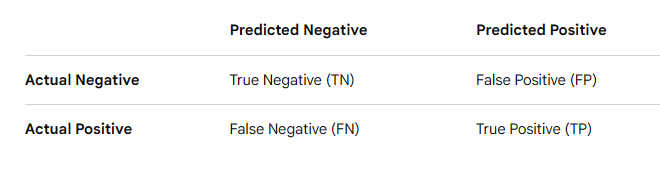

In [40]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81       106
           1       0.72      0.73      0.72        73

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



# ROC AUC Curve

In [41]:
y_test

862    1
223    0
84     1
680    0
535    1
      ..
796    1
815    0
629    0
421    0
448    1
Name: Survived, Length: 179, dtype: int64

In [42]:
y_prob = Pipe.predict_proba(x_test)[:,1]

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

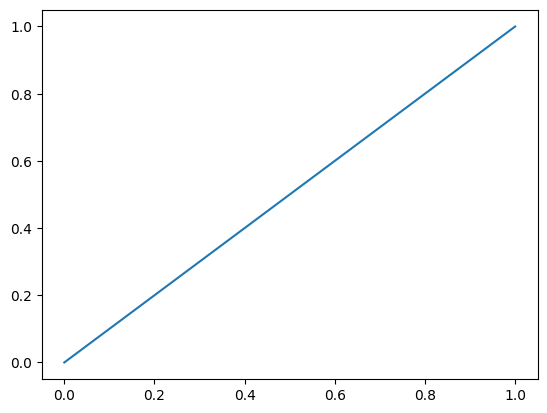

In [54]:
plt.plot(np.linspace(0,1,63),np.linspace(0,1,63))
plt.show()

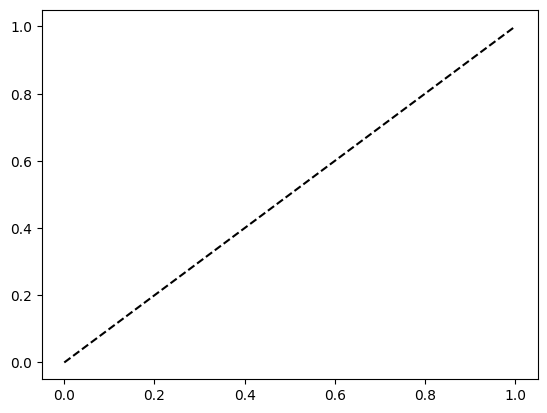

In [57]:
plt.plot([0,1],[0,1],"k--")

In [44]:
auc = roc_auc_score(y_test, y_prob)

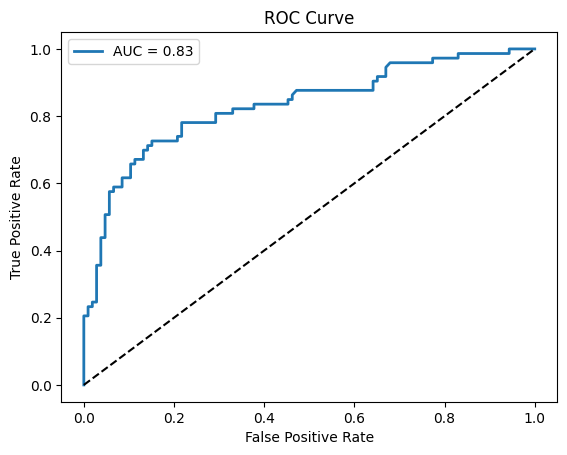

In [45]:
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()
